In [13]:
!pip3 install numpy
!pip3 install matplotlib
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

from utils import Plant # simulator

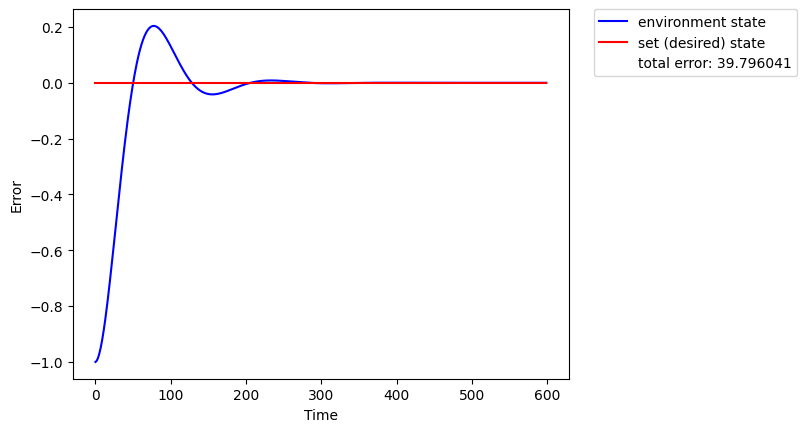

In [22]:
'''
don't change any code in this cell yet
'''
class PController(object):
    def __init__(self, Kp=0.5): # init function. the default Kp value here is 0.5
        self.Kp = Kp

    def update(self, error, delta_t):
        return error*self.Kp
kp = 0.2 # CHALLENGE 1: tune Kp here
controller = PController(kp) # declare and init a PController object. 

plant = Plant(controller, set_steady=True) # declare and init Plant (simulator)
plant.simulate()

In [34]:
class PIDController(object):

    def __init__(self, Kp=0.0, Ki=0.0, Kd=0.0):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.prev_error = 0.0
        self.accumulated_error = 0.0

    def update(self, error, delta_t):
        p = self.Kp * error

        #My code
        self.accumulated_error += error * delta_t
        i = self.Ki * self.accumulated_error

        #derivative of PD
        delta_e = error - self.prev_error
        d_e = delta_e / delta_t 
        d = self.Kd * d_e
        
        self.prev_error = error
        
        
        response = p + i + d
        return response


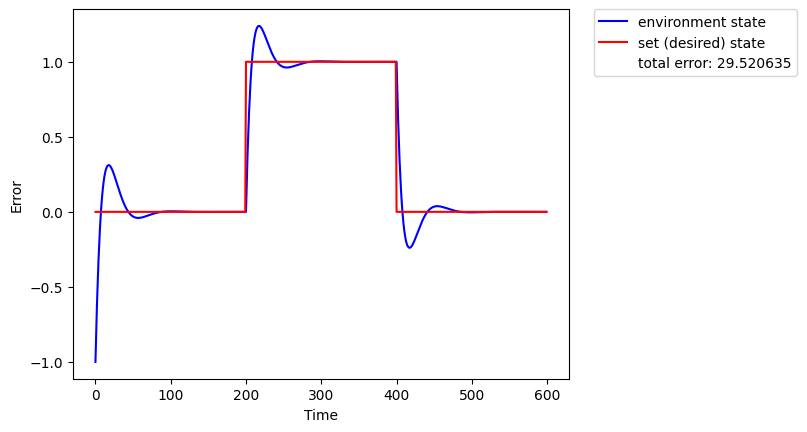

In [100]:
Kp = 2.0 #tune me!
Ki = 1.0 #tune me!
Kd = 1.8 #tune me!
controller = PIDController(Kp, Ki, Kd)

plant = Plant(controller, set_shift=True)
plant.simulate()